In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [3]:
insurance_data=pd.read_csv("data/insurance.csv")
print(insurance_data)

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]


In [4]:
x=insurance_data.drop(columns=["charges"])
y=insurance_data["charges"]

x=pd.get_dummies(x, columns=["region"], drop_first= True, dtype=int)

x["sex"]=x["sex"].map({"male": 0, "female": 1})
x["smoker"]=x["smoker"].map({"yes": 1, "no": 0})

x_train, x_test, y_train, y_test=train_test_split(
    x, y, test_size=0.2, random_state=43)

In [41]:
from sklearn.linear_model import LassoCV

a=[6,0.001, 0.01, 0.1 ,1, 2 ,3,4 , 5, 10, 30, 50, 100]

lasso_cv_model= LassoCV(
    alphas=a,
    cv=5,
    max_iter=1000,
    random_state=43

)
lasso_cv_model.fit(x_train, y_train)

print("best alpha = ", lasso_cv_model.alpha_)
    
y_pred=lasso_cv_model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
print("mse = ", mse)


best alpha =  30.0
mse =  42942562.37562522


<Axes: >

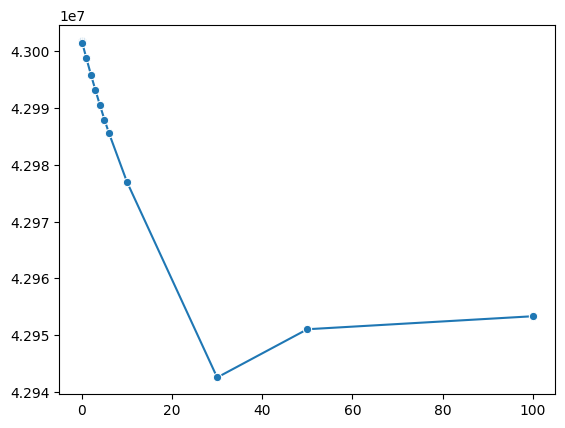

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(x=a, y=mess, marker="o")

In [6]:
y_pred=lasso_model.predict(x_test)
print(y_pred)

[ 8.27983598e+03  6.22845990e+03  2.65183517e+03  1.52135831e+04
  2.80981818e+04  9.89762869e+03  1.09118963e+04  7.21962459e+03
  9.75668011e+03  1.40144098e+03  2.73762637e+04  2.49489409e+04
  9.62511022e+03  9.43816924e+03  2.49877899e+03  5.25004330e+03
  2.84964252e+03  2.68989854e+04  7.02324387e+03  3.73456067e+03
  5.02833347e+03  1.21553473e+04  2.38498090e+03  1.14820443e+04
  7.06139460e+03  7.25206690e+03  1.09529570e+04  4.03992953e+04
  2.31424613e+03  1.25341319e+04  1.47941224e+04  3.20059150e+04
  1.54826874e+04  1.77109735e+03  1.21456768e+04  4.03910231e+03
  7.82562616e+03  1.25119529e+04  1.05018688e+04  5.67264617e+03
  2.78958183e+04  2.81583090e+04  3.70895497e+03  1.37955450e+04
  1.09712132e+04  3.43591950e+04  1.20942650e+04  2.98583874e+03
  2.72265694e+04  7.20919389e+03  9.61257034e+02  6.08161045e+03
  8.89011952e+03  3.25305924e+04  2.15414897e+03  1.95409816e+03
  6.71523931e+03  1.58976163e+04  3.12101752e+04  1.06196644e+04
  3.37410184e+04  3.74058

In [8]:
from sklearn.metrics import r2_score

r2=r2_score(y_test, y_pred)
print(r2)

0.6943010991470255


In [10]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

In [11]:
print(mse)

43001413.785859436
